# **EJERCICIO 3**

Primeramente, agregamos las librerias necesarias para el codigo.

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

Se carga la imagen después de almacenarla en el colab. Como OpenCV carga las imágenes en formato RGB y Matplotlib las trabaja en RGB, se convierte el orden de los canales.

In [14]:
# Cargar imagen
img = cv2.imread('/content/pajaro.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

El algoritmo KMeans necesita que los datos estén en formato bidimensional, por lo que se transforma la imagen en la matriz necesaria.

In [15]:
# Preparar datos para KMeans
pixel_vals = img_rgb.reshape((-1, 3))
pixel_vals = np.float32(pixel_vals)

Se aplica el algoritmo KMeans con un K = 3 para segmentar la imagen en 3 regiones basadas en su color.

In [16]:
# Aplicar KMeans
k = 3  # 3 regiones
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(pixel_vals)
labels = kmeans.labels_
centers = np.uint8(kmeans.cluster_centers_)

Se reconstruye la imagen segmentada.

In [17]:
# Crear imagen segmentada
segmented_img = centers[labels.flatten()]
segmented_img = segmented_img.reshape(img_rgb.shape)

Finalmente se visualiza la imagen original, la imagen segmentada en 3 regiones, así como tres imagenes representativas de cada una de las regiones.

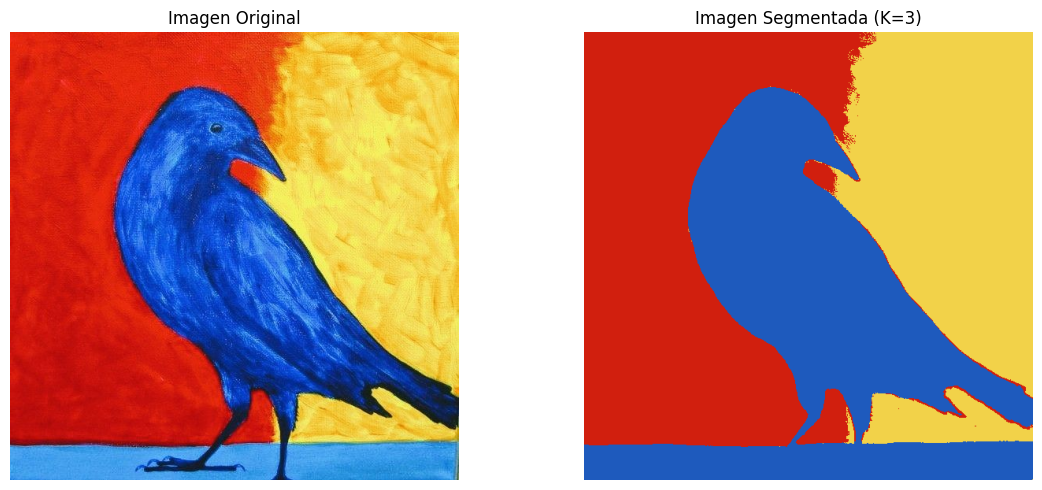

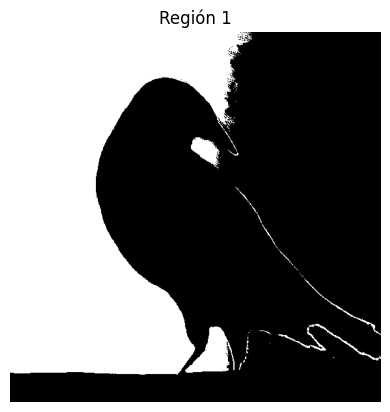

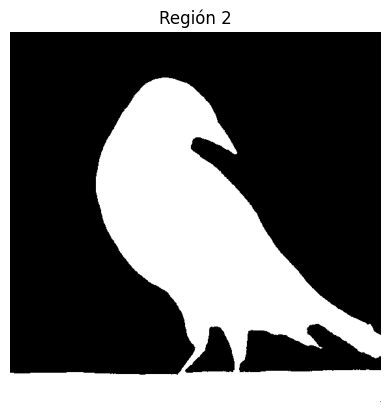

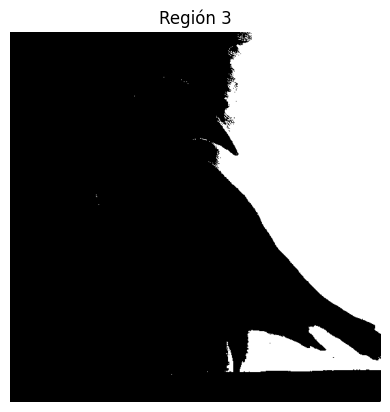

In [18]:
# Visualización
fig = plt.figure(figsize=(12, 5))

# Imagen original
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Imagen Original')
plt.axis('off')

# Imagen segmentada
plt.subplot(1, 2, 2)
plt.imshow(segmented_img)
plt.title(f'Imagen Segmentada (K={k})')
plt.axis('off')
plt.tight_layout()
plt.show()

# Mostrar cada región por separado
for i in range(k):
    mask = (labels == i)
    region = np.zeros_like(pixel_vals)
    region[mask] = centers[i]
    region = region.reshape(img_rgb.shape)

    plt.imshow(region)
    plt.title(f'Región {i+1}')
    plt.axis('off')
    plt.show()
